# 05 — Parameter Sweep & Heatmaps

**Goal:** avoid cherry-picking. We run *every* combination of moving-average window × leverage level × cost assumption, then ask a blunt question: **does any leveraged version beat buy-and-hold on all of CAGR, Sharpe, Calmar, and drawdown at once?**

In [1]:
# --- standard setup (run me first) ---
import sys, os
# Make the project root importable so `from src import ...` works from notebooks/.
sys.path.insert(0, os.path.abspath(".."))
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
print("Setup complete. Project root:", os.path.abspath(".."))

Setup complete. Project root: C:\Users\Taffy Jackson\leveraged-trend-following


In [2]:
from src import data_loader as dl, returns as rt, sweep as sw
from src import plots as pl, config

underlying, ticker, _ = dl.get_underlying_total_return()
u = rt.simple_returns(underlying)
rf = dl.get_risk_free_daily(u.index)

## Run the sweep (gross and net of costs)

In [3]:
scenarios = {'gross (0 cost)': config.ZERO_COSTS,
             'net (realistic)': config.DEFAULT_COSTS}
sweep = sw.run_parameter_sweep(underlying, u, rf_daily=rf,
                               cost_scenarios=scenarios)
sweep[sweep.strategy=='leveraged_bad_market'][[
    'cost_scenario','window','leverage','cagr','sharpe','max_drawdown','calmar']].head(12)

,cost_scenario,window,leverage,cagr,sharpe,max_drawdown,calmar
2,gross (0 cost),50.0000,1.0000,0.1139,0.5331,-0.5525,0.2062
3,gross (0 cost),50.0000,1.2500,0.1249,0.5331,-0.6077,0.2056
4,gross (0 cost),50.0000,1.5000,0.1346,0.5293,-0.6601,0.2040
5,gross (0 cost),50.0000,2.0000,0.1499,0.5189,-0.7643,0.1962
6,gross (0 cost),50.0000,2.5000,0.1596,0.5089,-0.8599,0.1856
7,gross (0 cost),50.0000,3.0000,0.1632,0.5006,-0.9235,0.1767
9,gross (0 cost),100.0000,1.0000,0.1158,0.5433,-0.5525,0.2095
10,gross (0 cost),100.0000,1.2500,0.1232,0.5283,-0.6338,0.1944
11,gross (0 cost),100.0000,1.5000,0.1294,0.5130,-0.7040,0.1838
12,gross (0 cost),100.0000,2.0000,0.1377,0.4864,-0.8139,0.1692


## Who beats buy-and-hold?

`beats_baseline` compares every *genuinely* leveraged config (>1x) to buy-and-hold. 'Beats all' means strictly better on CAGR **and** Sharpe **and** Calmar **and** drawdown.

In [4]:
for label in scenarios:
    beats = sw.beats_baseline(sweep, label)
    print(f'{label:18s}: beat on CAGR={beats.beats_cagr.sum():2d}, '
          f'Sharpe={beats.beats_sharpe.sum():2d}, '
          f'Calmar={beats.beats_calmar.sum():2d}, '
          f'ALL four={beats.beats_all.sum():2d}  (out of {len(beats)})')

gross (0 cost)    : beat on CAGR=25, Sharpe= 0, Calmar= 0, ALL four= 0  (out of 35)
net (realistic)   : beat on CAGR= 9, Sharpe= 0, Calmar= 0, ALL four= 0  (out of 35)


The 'ALL four' count is the honest scoreboard. If it is **zero**, then no leverage setting is unambiguously better than simply holding the index — higher returns always came with worse risk.

## Heatmaps: CAGR, Sharpe, max drawdown, Calmar

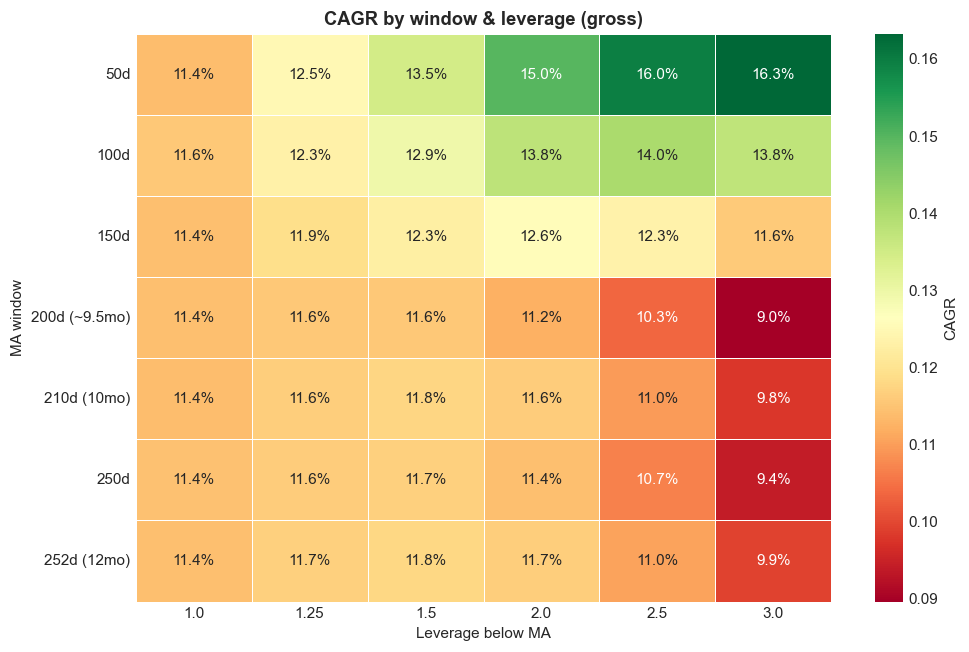

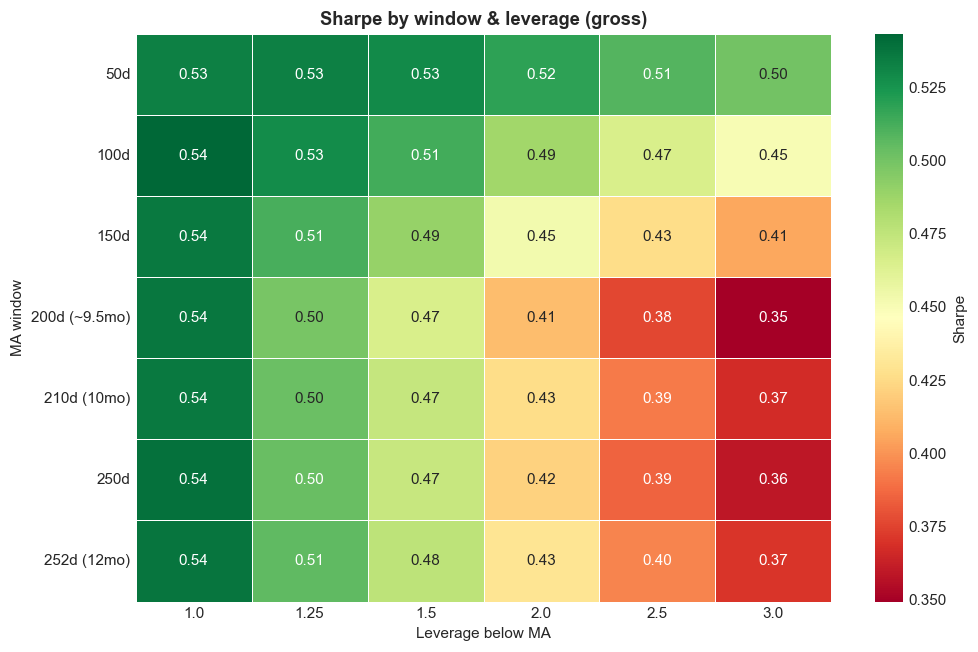

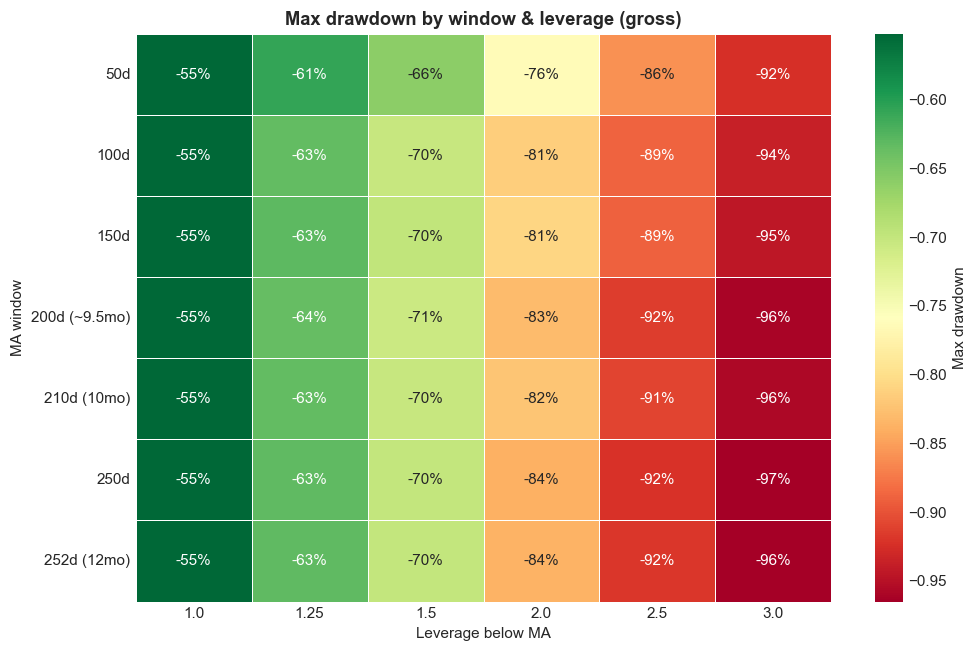

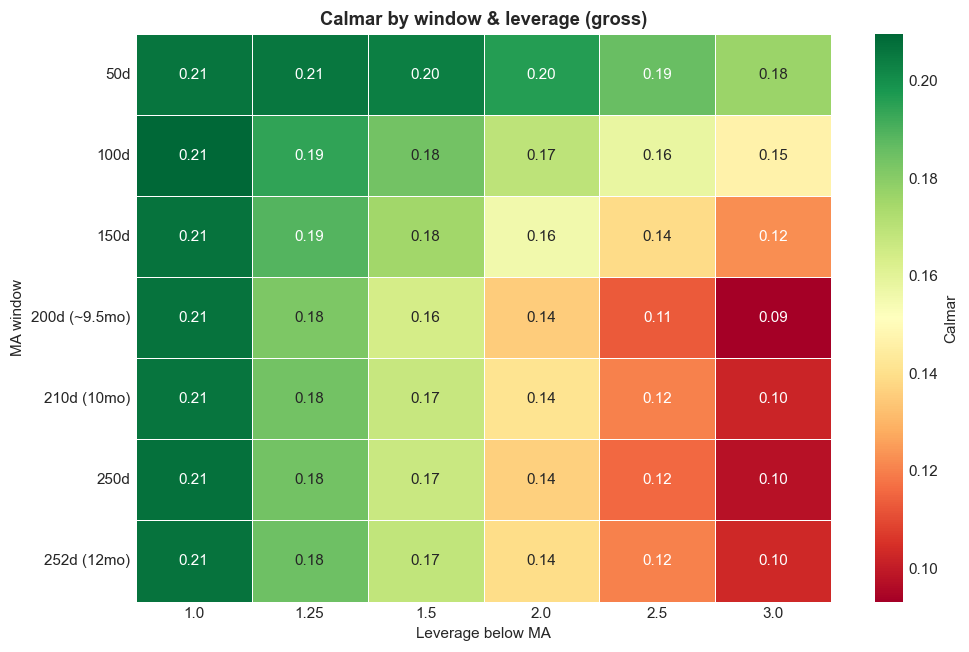

In [5]:
for value, fmt, cbar in [('cagr','.1%','CAGR'), ('sharpe','.2f','Sharpe'),
                         ('max_drawdown','.0%','Max drawdown'), ('calmar','.2f','Calmar')]:
    mat = sw.heatmap_matrix(sweep, value, 'gross (0 cost)')
    mat.index = [config.MA_WINDOW_LABELS.get(w, str(w)) for w in mat.index]
    fig = pl.plot_heatmap(mat, f'{cbar} by window & leverage (gross)',
        f'04_heatmap_{value}_gross.png', fmt=fmt, xlabel='Leverage below MA',
        ylabel='MA window', cbar_label=cbar)
    plt.show()

The CAGR heatmap may look tempting (greener to the right at low leverage), but compare it to the drawdown and Calmar heatmaps: risk rises faster than return as you move right. The best *risk-adjusted* cells sit at **low or no** leverage.

➡️ **Next:** notebook 06 checks whether real leveraged ETFs behave like our synthetic leverage.